In [ ]:
!pip install ultralytics opencv-python matplotlib requests


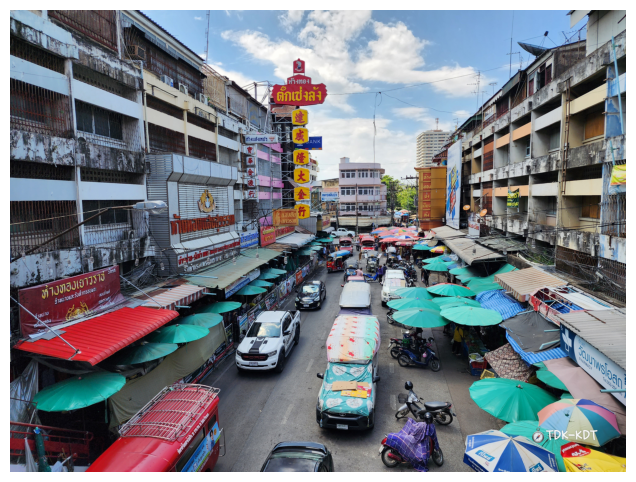

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import requests
import numpy as np

# โหลดโมเดล YOLOv8
model = YOLO("yolov8n.pt")  # ใช้โมเดล YOLOv8 (สามารถเปลี่ยนเป็น yolov8s.pt, yolov8m.pt, ฯลฯ)

# โหลดภาพจาก URL
url = "https://th.readme.me/f/45635/6492d959adf17272696d648b.jpg"

# แสดงภาพจาก URL
response = requests.get(url, stream=True).raw
image = np.asarray(bytearray(response.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)

# แสดงภาพก่อนการตรวจจับวัตถุ
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()  



0: 480x640 4 cars, 3 motorcycles, 1 bus, 11 umbrellas, 65.3ms
Speed: 6.3ms preprocess, 65.3ms inference, 4.2ms postprocess per image at shape (1, 3, 480, 640)


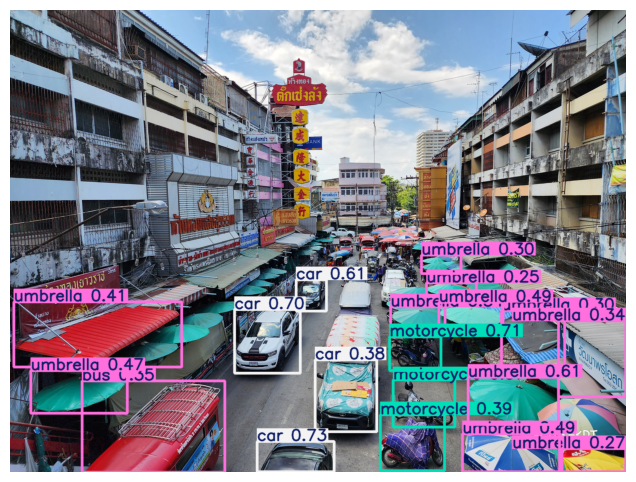

In [2]:
# รันการตรวจจับวัตถุ
results = model(image)

# วาดกล่องและป้ายชื่อบนภาพ
annotated_image = results[0].plot()

# แปลงภาพจาก BGR เป็น RGB สำหรับ matplotlib
image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

# แสดงภาพผลลัพธ์ด้วย matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")  # ซ่อนแกน
plt.show()